# Objectif du notebook 

Date de création : 08/02/2026

Application de la méthode de localisation RTF-MFP sur une séquence d'émission tractée n° 144/146. 

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_event_active")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, LargeFigure, color 
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2,
    get_dists,
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    FiberscopeManager,
    BandFilter,
)

# Chargement des données 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Construction de la librairie de répliques 

## Sélection des positions statiques de référence

In [5]:
n_highest = 8

# For comparison and simplicity we will use only emission with duration_s = 5s (short chirps)
df_arr_short = df_arr.loc[df_arr["duration_s"] == 5]

# df_arr_short = df_arr_short.loc[df_arr_short["deployed_length_m"] == '8']

df_arr_static = df_arr_short.loc[df_arr["src_pos_status"] == "fixed"]
src_pos_static = df_arr_static["src_pos_point"].unique()
for src_pos in src_pos_static:
    df_src_pos = df_arr_static.loc[df_arr["src_pos_point"] == src_pos]
    seq_src_pos = df_src_pos["sequence_id"].unique()
    print(f"Position {src_pos} -> sequence {seq_src_pos}")

    depth = []
    lvl = []
    max_psnr = []

    seq_mean_fscore = []
    # seq_mean_psnr = []
    for seq_id in seq_src_pos:
        df_seq_id = df_src_pos.loc[df_src_pos["sequence_id"] == seq_id]
        mean_f_score = (
            df_seq_id["f_score_obs1"].iloc[0]
            + df_seq_id["f_score_obs2"].iloc[0]
            + df_seq_id["f_score_obs3"].iloc[0]
        ) / 3
        seq_mean_fscore.append(mean_f_score)

        psnr = np.max(
            (df_seq_id["psnr_obs1"] + df_seq_id["psnr_obs2"] + df_seq_id["psnr_obs3"]) / 3
        )
        max_psnr.append(psnr)

        depth.append(df_seq_id["deployed_length_m"].iloc[0])
        lvl.append(df_seq_id["board_voltage_v"].iloc[0])

    seq_mean_fscore = np.array(seq_mean_fscore)
    depth = np.array(depth)
    lvl = np.array(lvl)

    idx_sorted_fscore = np.argsort(seq_mean_fscore)[::-1]
    seq_mean_fscore_sorted = seq_mean_fscore[idx_sorted_fscore]
    seq_src_pos_sorted = seq_src_pos[idx_sorted_fscore]
    depth = depth[idx_sorted_fscore]
    lvl = lvl[idx_sorted_fscore]

    # Sel the n_highest scores
    print(f"\tTop {n_highest} sequences with highest f-score")
    seq_fscore_selection = seq_mean_fscore_sorted[:n_highest]
    seq_selection = seq_src_pos_sorted[:n_highest]
    for i in range(seq_selection.size):
        print(
            f"\t\tSequence {seq_selection[i]} -> {seq_mean_fscore_sorted[i]} ({depth[i]}m, lvl={lvl[i]}, psnr={max_psnr[i]}) "
        )

    # df_arr_plot = df_arr.loc[df_arr["src_pos_point"] == "4"]

Position 1 -> sequence [12 13 14 15 16 24 25 26 27 28 29]
	Top 8 sequences with highest f-score
		Sequence 24 -> 0.7472044764119117 (5m, lvl=4.0, psnr=88.34554396573766) 
		Sequence 12 -> 0.7289492450517466 (2m, lvl=4.0, psnr=67.70796225848493) 
		Sequence 13 -> 0.7179557900659793 (2m, lvl=2.0, psnr=36.89219949776674) 
		Sequence 25 -> 0.7001631818092378 (5m, lvl=2.0, psnr=18.120941813290386) 
		Sequence 14 -> 0.6931016552858357 (2m, lvl=1.0, psnr=nan) 
		Sequence 26 -> 0.6799971744453309 (5m, lvl=1.0, psnr=108.17228150908511) 
		Sequence 15 -> 0.6603463487590043 (2m, lvl=0.5, psnr=45.71747374110263) 
		Sequence 27 -> 0.24045919816420294 (5m, lvl=0.5, psnr=18.29277480788976) 
Position 2 -> sequence [35 39 40 41 42 43 44 47 51]
	Top 8 sequences with highest f-score
		Sequence 51 -> 0.7668708549928365 (8m, lvl=4.0, psnr=117.06146256278312) 
		Sequence 35 -> 0.7526367762885862 (2m, lvl=4.0, psnr=95.3677406633393) 
		Sequence 39 -> 0.7480880771916217 (5m, lvl=4.0, psnr=48.205591834718945) 

In [6]:
# Keep only the best sequence for each position
# 4V and d = 5m (highest fscore)
# selected_static_sequences = [155, 116, 131, 24, 39, 59, 80, 95]

# Highest mean psnr
selected_static_sequences = [155, 116, 143, 24, 51, 55, 80, 95]

# 2V
# selected_static_sequences = [156, 117, 132, 25, 40, 60, 81, 95]

# # 1V
# selected_static_sequences = [157, 118, 133, 26, 41, 61, 82, 101]

# OBS 1 and 3, 4V and different immersions
# selected_static_sequences = [151, 155, 167, 127, 131, 143]

# OBS 1 and 3, 5m and different lvl
# selected_static_sequences = [155, 156, 157, 158, 131, 132, 133, 134]


# selected_static_sequences = [116]


# selected_static_sequences = [151, 51]
# selected_static_sequences = [151, 116, 143, 24, 51, 55, 90, 95]       # first
# selected_static_sequences = [155, 117, 127, 12, 35, 59, 80, 110]        # second best

# First at 5m
# selected_static_sequences = [151, 116, 143, 26, 35, 59, 80, 110]

# Pos S
# selected_static_sequences = [151, 155, 167, 116, 117, 118, 143, 127, 131]
# selected_static_sequences = [151, 156, 157, 116, 118, 119, 143, 132, 133]


df_library = df_arr_static.loc[df_arr_static["sequence_id"].isin(selected_static_sequences)]

In [7]:
library_dict = {}
for seq_id in selected_static_sequences:
    src_pos = df_library.loc[df_library["sequence_id"] == seq_id].iloc[0].src_pos_point
    library_dict[seq_id] = src_pos

library_dict

{155: '1S', 116: '2S', 143: '3S', 24: '1', 51: '2', 55: '3', 80: '4', 95: '5'}

## Calcul des répliques (RTF)

In [8]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

rtf_estimator = "cs-evd"

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response 
# tau_rtf_analysis = 10 * tau_ir_hat  # To ensure we include the entire response
tau_rtf_analysis = 3

fs = 2000
# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)

print(f"tau = {tau_rtf_analysis}s")
print(f"nperseg = {nperseg} ({nperseg * 1/fs}s), noverlap = {noverlap}")

fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# fsm.process_static_analysis(
#     df_arrivals=df_library,
#     set_stft_props=False,
#     verbose=False,
# )

tau = 3s
nperseg = 8192 (4.096s), noverlap = 6144


# Source event à localiser : source tractée 

In [9]:
event_seq_id = 144
df_event = df_arr.loc[df_arr["sequence_id"] == event_seq_id]

root_fig = os.path.join(rtf_mfp_img_folder, f"trailed_{event_seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

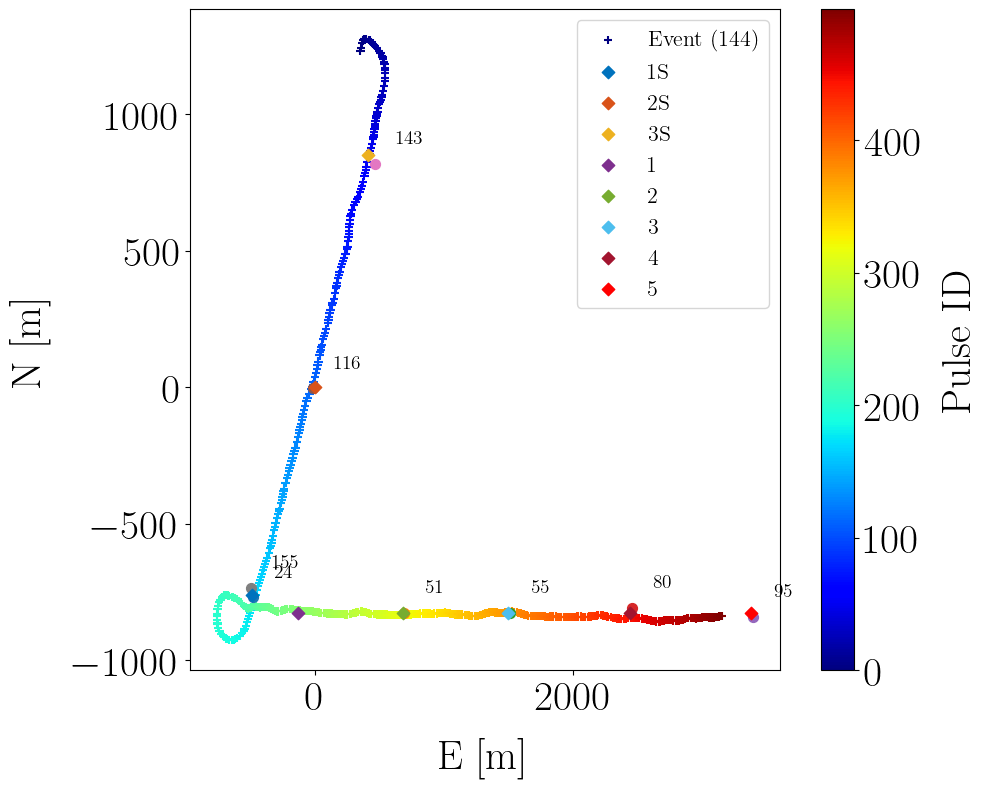

In [10]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_event

seq_mean_fscore = []

pfig = PubFigure(size=(10,8), legend_fontsize=16)
# Plot
plt.figure()
for i, seq_id in enumerate(df_arr_plot["sequence_id"].unique()):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)

    # Série de positions successives
    plt.scatter(
        df_sequence["emission_interp_e_gps"],
        df_sequence["emission_interp_n_gps"],
        marker="+",
        label=f"Event ({seq_id})",
        c=np.arange(df_sequence["emission_interp_e_gps"].size),
        cmap="jet"
    )
plt.colorbar(label="Pulse ID")


for i, seq_id in enumerate(df_library["sequence_id"].unique()):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    plt.scatter(
        x=df_sequence["emission_interp_e_gps"].iloc[0],
        y=df_sequence["emission_interp_n_gps"].iloc[0],
        marker="o",
        # color="m",
        s=50,
    )
    plt.annotate(
        seq_id,
        (
            df_sequence["emission_interp_e_gps"].iloc[0],
            df_sequence["emission_interp_n_gps"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(15, 15),
        ha="left",
        fontsize=14,
        # color="m",
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
label = {
    "obs1": "1S",
    "obs2": "2S",
    "obs3": "3S",
    "t1": "1",
    "t2": "2",
    "t3": "3",
    "t4": "4",
    "t5": "5",
}
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=label[k],
        zorder=10,
        color=color(ik),
        s=40,
    )

plt.legend()

fpath = os.path.join(root_fig, "trailed_trajectory.png")
plt.savefig(fpath)

In [11]:
tau_rtf_analysis = 3

bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

# h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# # Comment below if already computed
# fsm.process_static_analysis(
#     df_arrivals=df_event,
#     set_stft_props=False,
#     verbose=False,
# )

# Compute ambiguity distance 

In [12]:
# Analyse rtf variations
fmin = 500      
fmax = 900

seq_library = df_library["sequence_id"].unique()
seq_event = df_event["sequence_id"].unique()[0]

In [13]:
spatial_dist_obs = {}
theta_dist_obs = {}
for seq_id_ref in seq_library:
    theta_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_seq, df_seq = get_dists_2(
        fsm=fsm,
        df_arr=df_arr,
        seq_id_ref=seq_id_ref,
        seq_id=seq_event,
        fmin=fmin,
        fmax=fmax,
        dist_type="hermitian_angle",
    )

    idx_pulse_min = np.argmin(theta_dist, axis=1)
    theta_dist = np.array([theta_dist[i, idx_pulse_min[i]] for i in range(theta_dist.shape[0])])
    spatial_dist = np.array(
        [spatial_dist[i, idx_pulse_min[i]] for i in range(spatial_dist.shape[0])]
    )
    # theta_dist, spatial_dist, xr_seq, df_seq = get_dists(
    #     fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax
    # )

    # Store in dict
    # src_pos = df_library.loc[df_library["sequence_id"] == seq_id_ref].iloc[0].src_pos_point
    src_pos = library_dict[seq_id_ref]
    theta_dist_obs[src_pos] = {
        "id": seq_id_ref,
        "theta": theta_dist
    }
    spatial_dist_obs[src_pos] = {"id": seq_id_ref, "r": spatial_dist}

    # spatial_dist_obs.append(spatial_dist)
    # euc__dist_obs.append(theta_dist)

# spatial_dist_obs = np.array(spatial_dist_obs)
# theta_dist_obs = np.array(theta_dist_obs)

Compute distance using hermitian angle distance (in C^N)
Compute distance using hermitian angle distance (in C^N)


In [ ]:
src_pos_order = ["3S", "2S", "1S", "1", "2", "3", "4", "5"]
pulse_id = xr_seq.pulse_id.values
pulse_dt = df_seq["emission_datetime"]

In [ ]:
for pos in src_pos_order:
    idx_dist_min = np.argmin(spatial_dist_obs[pos]["r"])
    print(f"{pos} -> dist min for pulse id {idx_dist_min} (d = {spatial_dist_obs[pos]['r'][idx_dist_min]})")


In [ ]:
n_roll_avg = 1
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)

fig, axs = plt.subplots(2, 1, sharex=True)
fig.suptitle(f"Event {event_seq_id} (trailed)")

for pos in src_pos_order:
    theta_roll_i = np.convolve(
        theta_dist_obs[pos]["theta"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )

    axs[0].plot(pulse_dt, theta_roll_i, label=f"{pos} ({theta_dist_obs[pos]['id']})")
    axs[0].legend(ncol=4, loc="upper right")

    axs[1].plot(pulse_dt, spatial_dist_obs[pos]["r"], label=f"{pos} ({theta_dist_obs[pos]['id']})")
    axs[1].legend(ncol=4, loc="upper right")

axs[0].set_ylabel(r"$\theta$ [°]")
axs[1].set_ylabel("Distance [m]")

# Subfigure annotations
# axs[0].text(
#     1.0,
#     1.02,
#     "(a)",
#     transform=axs[0].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )

# axs[1].text(
#     1.0,
#     1.02,
#     "(b)",
#     transform=axs[1].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )
# Subfigure annotations
axs[0].text(
    0.01,
    0.95,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[1].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)



fig.supxlabel("Temps UTC")
fpath = os.path.join(root_fig, "theta_and_dist_vs_time.png")
plt.savefig(fpath)

In [ ]:
# # Sort by increasing distance
plt.figure()
plt.title(f"Event {event_seq_id} (trailed)")
for pos in theta_dist_obs.keys():
    dist_to_ref_argsort = np.argsort(spatial_dist_obs[pos]["r"])
    sorted_spatial_dist = spatial_dist_obs[pos]["r"][dist_to_ref_argsort]
    sorted_theta_dist = theta_dist_obs[pos]["theta"][dist_to_ref_argsort]

    plt.scatter(
        sorted_spatial_dist,
        sorted_theta_dist,
        label=f"{pos} ({theta_dist_obs[pos]['id']})",
    )
plt.xlabel('Spatial distance [m]')
plt.ylabel(r"$\theta$ [°]")
plt.legend()
# plt.xlim(0, 500)

fpath = os.path.join(root_fig, "theta_vs_sorted_range.png")
plt.savefig(fpath)

In [ ]:
nwrap = 4
npos = len(spatial_dist_obs.keys())
nrow = npos // nwrap
ncol = npos // nrow + npos % nrow

import string
labels = list(string.ascii_lowercase)

lfig = LargeFigure(size=(16, 10), legend_fontsize=12)
fig, axs = plt.subplots(nrow, ncol, sharex=True, sharey=True)
axs = axs.flatten()

for i, pos in enumerate(src_pos_order):
    dist_to_ref_argsort = np.argsort(spatial_dist_obs[pos]["r"])
    sorted_spatial_dist = spatial_dist_obs[pos]["r"][dist_to_ref_argsort]
    sorted_theta_dist = theta_dist_obs[pos]["theta"][dist_to_ref_argsort]

    # Plot
    axs[i].scatter(
        sorted_spatial_dist,
        sorted_theta_dist,
        s=15,
        color=color(i)
    )

    # Linear regression
    r_max = 800
    if r_max > sorted_spatial_dist.min():
        r_dist = sorted_spatial_dist[sorted_spatial_dist <= r_max]
        theta_dist = sorted_theta_dist[sorted_spatial_dist <= r_max]
        slope, intercept, r, p, se = linregress(r_dist, theta_dist)
        r_ = np.linspace(0, r_max, 1000)
        y = intercept + slope * r_

        axs[i].plot(
            r_,
            y,
            linestyle="--",
            color="k",
            label=rf"$\theta = {{{intercept:.2f}}} + {{{slope:.2f}}} \times r \,(r^2 = {{{r**2:.2f}}})$",
        )

        axs[i].legend(loc="lower right")
    axs[i].set_title(f"{pos} ({theta_dist_obs[pos]['id']})")

    # Subfigure annotation
    axs[i].text(
        0.02,
        0.98,
        f"({labels[i]})",
        transform=axs[i].transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )



fig.suptitle(f"Event {event_seq_id} (trailed)")
fig.supxlabel("Distance to library replica location [m]")
fig.supylabel(r"$\theta$ [°]")

fpath = os.path.join(root_fig, "theta_vs_sorted_range_panels.png")
plt.savefig(fpath)

In [ ]:
# from pydiffmap import diffusion_map as dm
# from sklearn.manifold import Isomap

# d = 1
# neighbor_params = {"n_jobs": -1, "algorithm": "ball_tree"}
# # initialize Diffusion map object.
# mydmap = dm.DiffusionMap.from_sklearn(
#     n_evecs=d, k=10, epsilon="bgh", alpha=1.0, neighbor_params=neighbor_params
# )


# # Load rtf data
# seq_event = 144  # Séquence tractée
# fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_event}_rtf.nc")
# xr_seq_event = xr.open_dataset(fpath)
# df_seq_event = df_arr.loc[df_arr["sequence_id"] == seq_event]
# df_seq_event = df_seq_event.loc[
#     df_seq_event["pulse_id"].isin(xr_seq_event.pulse_id.values)
# ]
# rtf_event = xr_seq_event.rtf_amp_hat
# # rtf_event = xr_seq_event.rtf_amp_hat * np.exp(1j * xr_seq_event.rtf_phase_hat)

# nwrap = 4
# npos = len(spatial_dist_obs.keys())
# nrow = npos // nwrap
# ncol = npos // nrow + npos % nrow

# labels = list(string.ascii_lowercase)

# lfig = LargeFigure(size=(16, 10), legend_fontsize=12)
# fig, axs = plt.subplots(nrow, ncol, sharex=True, sharey=True)
# axs = axs.flatten()

# X_all = np.concatenate(
#     (
#         rtf_event.sel(h_index=2).isel(pulse_id=slice(0, 200)).values,
#         rtf_event.sel(h_index=3).isel(pulse_id=slice(0, 200)).values,
#     ),
#     axis=1,
# )
# # X_all_ = np.abs(X_augmented
# emb = Isomap(n_neighbors=100, n_components=d)
# X_isomap_mod = emb.fit_transform(X=X_all)
# X_isomap_data = X_isomap_mod.T

# # # fit to data and return the diffusion map.
# # X_diffmap = mydmap.fit_transform(X_all)

# # print(mydmap.epsilon_fitted)

# # X_diffmap_data = X_diffmap[:, :].T


# for i, pos in enumerate(src_pos_order):
#     dist_to_ref_argsort = np.argsort(spatial_dist_obs[pos]["r"])
#     sorted_spatial_dist = spatial_dist_obs[pos]["r"][dist_to_ref_argsort]
#     sorted_theta_dist = theta_dist_obs[pos]["theta"][dist_to_ref_argsort]

#     seq_lib = spatial_dist_obs[pos]["id"]  # Séquence correspondant à la position pos

#     fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_lib}_rtf.nc")
#     xr_seq_lib = xr.open_dataset(fpath)
#     df_seq_lib = df_arr.loc[df_arr["sequence_id"] == seq_lib]
#     df_seq_lib = df_seq_lib.loc[df_seq_lib["pulse_id"].isin(xr_seq_lib.pulse_id.values)]
#     rtf_lib = xr_seq_lib.rtf_amp_hat.isel(pulse_id=0)
#     # rtf_lib = xr_seq_lib.rtf_amp_hat * np.exp(1j * xr_seq_lib.rtf_phase_hat)

#     # X_ref = rtf_lib.sel(h_index=3).values
#     # X_augmented = np.concatenate(
#     #     (rtf_event.sel(h_index=3).values, X_ref[:, np.newaxis]), axis=1
#     # ).T
#     # # Module
#     # X_augmented_mod = np.abs(X_augmented)

#     # emb = Isomap(n_neighbors=30, n_components=d)
#     # X_isomap_mod = emb.fit_transform(X=X_augmented_mod)
#     # X_isomap_data = X_isomap_mod[:-1, :].T
#     # X_isomap_ref = X_isomap_mod[-1:, :].T
#     X_isomap_ref = rtf_lib.sel(h_index=3).values

#     d_isomap = np.linalg.norm(X_isomap_data - X_isomap_ref, axis=0)
#     d_isomap /= np.max(d_isomap)
#     d_isomap_sorted = d_isomap[dist_to_ref_argsort]

#     axs[i].plot(sorted_spatial_dist, d_isomap_sorted, color=color(i))
#     # axs[i].set_xlim(0, 1000)
#     # # Apply diffusion

#     # # fit to data and return the diffusion map.
#     # X_diffmap = mydmap.fit_transform(X_augmented_mod)

#     # print(mydmap.epsilon_fitted)

#     # X_diffmap_data = X_diffmap[:-1, :].T
#     # X_diffmap_ref = X_diffmap[-1:, :].T

#     # d_diffusion = np.linalg.norm(X_diffmap_data - X_diffmap_ref, axis=0)

#     # # Plot
#     # axs[i].scatter(
#     #     sorted_spatial_dist,
#     #     sorted_theta_dist,
#     #     s=15,
#     #     color=color(i)
#     # )

#     # # Linear regression
#     # r_max = 800
#     # if r_max > sorted_spatial_dist.min():
#     #     r_dist = sorted_spatial_dist[sorted_spatial_dist <= r_max]
#     #     theta_dist = sorted_theta_dist[sorted_spatial_dist <= r_max]
#     #     slope, intercept, r, p, se = linregress(r_dist, theta_dist)
#     #     r_ = np.linspace(0, r_max, 1000)
#     #     y = intercept + slope * r_

#     #     axs[i].plot(
#     #         r_,
#     #         y,
#     #         linestyle="--",
#     #         color="k",
#     #         label=rf"$\theta = {{{intercept:.2f}}} + {{{slope:.2f}}} \times r \,(r^2 = {{{r**2:.2f}}})$",
#     #     )

#     #     axs[i].legend(loc="lower right")

#     axs[i].set_title(f"{pos} ({theta_dist_obs[pos]['id']})")

#     # Subfigure annotation
#     axs[i].text(
#         0.02,
#         0.98,
#         f"({labels[i]})",
#         transform=axs[i].transAxes,
#         fontsize=14,
#         fontweight="bold",
#         ha="left",
#         va="top",
#         clip_on=False,
#     )


# fig.suptitle(f"Event {event_seq_id} (trailed)")
# fig.supxlabel("Distance to library replica location [m]")
# fig.supylabel(r"$\theta$ [°]")

# # fpath = os.path.join(root_fig, "theta_vs_sorted_range_panels.png")
# # plt.savefig(fpath)

### Commentaires 

La distance theta varie linéairement avec la distance sur un domaine de distance restreint. 

Ceci est en accord avec l'existence d'une varieté acoustique : espace localement euclidien.  

# Étude de la distance Euclidienne

In [ ]:
spatial_dist_obs = {}
euc_dist_obs = {}
for seq_id_ref in seq_library:
    euc_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_seq, df_seq = get_dists_2(
        fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax, dist_type="euclidean"
    )

    idx_pulse_min = np.argmin(euc_dist, axis=1)
    euc_dist = np.array(
        [euc_dist[i, idx_pulse_min[i]] for i in range(euc_dist.shape[0])]
    )
    spatial_dist = np.array(
        [spatial_dist[i, idx_pulse_min[i]] for i in range(spatial_dist.shape[0])]
    )
    # euc_dist, spatial_dist, xr_seq, df_seq = get_dists(
    #     fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax
    # )

    # Store in dict
    src_pos = library_dict[seq_id_ref]
    euc_dist_obs[src_pos] = {"id": seq_id_ref, "d": euc_dist}
    spatial_dist_obs[src_pos] = {"id": seq_id_ref, "r": spatial_dist}

In [ ]:
src_pos_order = ["3S", "2S", "1S", "1", "2", "3", "4", "5"]
pulse_id = xr_seq.pulse_id.values
pulse_dt = df_seq["emission_datetime"]

In [ ]:
for pos in src_pos_order:
    idx_dist_min = np.argmin(spatial_dist_obs[pos]["r"])
    print(f"{pos} -> dist min for pulse id {idx_dist_min} (d = {spatial_dist_obs[pos]['r'][idx_dist_min]})")


In [ ]:
n_roll_avg = 1
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)

fig, axs = plt.subplots(2, 1, sharex=True)
fig.suptitle(f"Event {event_seq_id} (trailed)")

for pos in src_pos_order:
    euc_roll_i = np.convolve(
        euc_dist_obs[pos]["d"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )

    axs[0].plot(pulse_dt, euc_roll_i, label=f"{pos} ({euc_dist_obs[pos]['id']})")
    axs[0].legend(ncol=4, loc="upper right")

    axs[1].plot(
        pulse_dt, spatial_dist_obs[pos]["r"], label=f"{pos} ({euc_dist_obs[pos]['id']})"
    )
    axs[1].legend(ncol=4, loc="upper right")

axs[0].set_ylabel(r"$d_{\text{Euc}}$")
axs[1].set_ylabel("Distance [m]")

# Subfigure annotations
# axs[0].text(
#     1.0,
#     1.02,
#     "(a)",
#     transform=axs[0].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )

# axs[1].text(
#     1.0,
#     1.02,
#     "(b)",
#     transform=axs[1].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )
# Subfigure annotations
axs[0].text(
    0.01,
    0.95,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[1].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)


fig.supxlabel("Temps UTC")
fpath = os.path.join(root_fig, "d_euc_and_dist_vs_time.png")
plt.savefig(fpath)

In [ ]:
# # Sort by increasing distance
plt.figure()
plt.title(f"Event {event_seq_id} (trailed)")
for pos in euc_dist_obs.keys():
    dist_to_ref_argsort = np.argsort(spatial_dist_obs[pos]["r"])
    sorted_spatial_dist = spatial_dist_obs[pos]["r"][dist_to_ref_argsort]
    sorted_euc_dist = euc_dist_obs[pos]["d"][dist_to_ref_argsort]

    plt.scatter(
        sorted_spatial_dist,
        sorted_euc_dist,
        label=f"{pos} ({euc_dist_obs[pos]['id']})",
    )
plt.xlabel('Spatial distance [m]')
plt.ylabel(r"$d_{\text{Euc}}$")
plt.legend()
# plt.xlim(0, 500)

fpath = os.path.join(root_fig, "d_euc_vs_sorted_range.png")
plt.savefig(fpath)

In [ ]:
nwrap = 4
npos = len(spatial_dist_obs.keys())
nrow = npos // nwrap
ncol = npos // nrow + npos % nrow

import string
labels = list(string.ascii_lowercase)

lfig = LargeFigure(size=(16, 10), legend_fontsize=12)
fig, axs = plt.subplots(nrow, ncol, sharex=True, sharey=True)
axs = axs.flatten()

for i, pos in enumerate(src_pos_order):
    dist_to_ref_argsort = np.argsort(spatial_dist_obs[pos]["r"])
    sorted_spatial_dist = spatial_dist_obs[pos]["r"][dist_to_ref_argsort]
    sorted_euc_dist = euc_dist_obs[pos]["d"][dist_to_ref_argsort]

    # Plot
    axs[i].scatter(sorted_spatial_dist, sorted_euc_dist, s=15, color=color(i))

    # Linear regression
    r_max = 800
    if r_max > sorted_spatial_dist.min():
        r_dist = sorted_spatial_dist[sorted_spatial_dist <= r_max]
        euc_dist = sorted_euc_dist[sorted_spatial_dist <= r_max]
        slope, intercept, r, p, se = linregress(r_dist, euc_dist)
        r_ = np.linspace(0, r_max, 1000)
        y = intercept + slope * r_

        axs[i].plot(
            r_,
            y,
            linestyle="--",
            color="k",
            label=rf"$d = {{{intercept:.2f}}} + {{{slope:.2f}}} \times r \,(r^2 = {{{r**2:.2f}}})$",
        )

        axs[i].legend(loc="upper right")
    axs[i].set_title(f"{pos} ({euc_dist_obs[pos]['id']})")

    # Subfigure annotation
    axs[i].text(
        0.02,
        0.98,
        f"({labels[i]})",
        transform=axs[i].transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )


fig.suptitle(f"Event {event_seq_id} (trailed)")
fig.supxlabel("Distance to library replica location [m]")
fig.supylabel(r"$d_{\text{Euc}}$")

fpath = os.path.join(root_fig, "d_euc_vs_sorted_range_panels.png")
plt.savefig(fpath)

# Comparaison des vecteurs de RTF pour une position donnée
On s'intéresse aux vecteurs de RTFs associés aux positions le long du transect pour lesquelles la distance $\theta$ ne présente pas de minimum. 

In [ ]:
from propa.rtf.rtf_utils import D_hermitian_angle_fast

dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_median": True}

In [ ]:
pos = '1S'
seq_lib = spatial_dist_obs[pos]["id"]      # Séquence correspondant à la position pos
seq_event = 144     # Séquence tractée 

idx_obs = 3

n_offset = 2

# Load rtf data
fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_lib}_rtf.nc")
xr_seq_lib= xr.open_dataset(fpath)
df_seq_lib = df_arr.loc[df_arr["sequence_id"] == seq_lib]
df_seq_lib = df_seq_lib.loc[df_seq_lib["pulse_id"].isin(xr_seq_lib.pulse_id.values)]
rtf_lib = xr_seq_lib.rtf_amp_hat


fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_event}_rtf.nc")
xr_seq_event = xr.open_dataset(fpath)
df_seq_event = df_arr.loc[df_arr["sequence_id"] == seq_event]
df_seq_event = df_seq_event.loc[
    df_seq_event["pulse_id"].isin(xr_seq_event.pulse_id.values)
]
rtf_event = xr_seq_event.rtf_amp_hat

rtf_lib = rtf_lib.sel(h_index=idx_obs)
rtf_event = rtf_event.sel(h_index=idx_obs)

# Get the pulses of interest
idx_pulse_min_dist = np.argmin(spatial_dist_obs[pos]["r"])      # Index of the pulse emitted at the closest dist to lib pos 
pulse_slice = slice(
    max(idx_pulse_min_dist - n_offset, 0),
    min(idx_pulse_min_dist + n_offset + 1, spatial_dist_obs[pos]["r"].size),
)
print(pulse_slice)

# idx_pulse_min_theta = np.argmin(theta_dist_obs[pos]["theta"], axis=1)
# print(idx_pulse_min_theta[pulse_slice])

# Slice all variables
spatial_dist_slice = spatial_dist_obs[pos]["r"][pulse_slice]
theta_dist_slice = theta_dist_obs[pos]["theta"][pulse_slice]
rtf_event = rtf_event.isel(pulse_id=pulse_slice)

n = pulse_slice.stop - pulse_slice.start
fig, axs = plt.subplots(nrows=n, ncols=1, sharex=True)

for i in range(n):
    rtf_lib.plot(x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i])
    rtf_event.isel(pulse_id=i).plot(x="f_rtf", color="k", ax=axs[i], label="Event")

    axs[i].set_ylim(
        rtf_event.isel(pulse_id=i).min().values, rtf_event.isel(pulse_id=i).max().values
    )

    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    # axs[i].set_ylim(min_amp, max_amp)
    axs[i].set_yscale("log")
    axs[i].set_title("")
    axs[i].legend(fontsize=8)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
plt.xlim(fmin, fmax)
# plt.xlim(600,700)
# plt.xlim(200, fmin)

In [ ]:
pos = "2"
seq_lib = spatial_dist_obs[pos]["id"]  # Séquence correspondant à la position pos
seq_event = 144  # Séquence tractée

n_offset = 2

# Load rtf data
fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_lib}_rtf.nc")
xr_seq_lib = xr.open_dataset(fpath)
df_seq_lib = df_arr.loc[df_arr["sequence_id"] == seq_lib]
df_seq_lib = df_seq_lib.loc[df_seq_lib["pulse_id"].isin(xr_seq_lib.pulse_id.values)]


fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_event}_rtf.nc")
xr_seq_event = xr.open_dataset(fpath)
df_seq_event = df_arr.loc[df_arr["sequence_id"] == seq_event]
df_seq_event = df_seq_event.loc[
    df_seq_event["pulse_id"].isin(xr_seq_event.pulse_id.values)
]

# Select the frequency band of interest
xr_seq_lib = xr_seq_lib.sel(f_rtf=slice(fmin, fmax))
xr_seq_event = xr_seq_event.sel(f_rtf=slice(fmin, fmax))

rtf_lib_amp = xr_seq_lib.rtf_amp_hat
rtf_event_amp = xr_seq_event.rtf_amp_hat

rtf_lib = xr_seq_lib.rtf_amp_hat * np.exp(1j * xr_seq_lib.rtf_phase_hat)
rtf_event = xr_seq_event.rtf_amp_hat * np.exp(1j * xr_seq_event.rtf_phase_hat)

# Get the pulses of interest
idx_pulse_min_dist = np.argmin(
    spatial_dist_obs[pos]["r"]
)  # Index of the pulse emitted at the closest dist to lib pos
# idx_pulse_min_dist = np.argmin(
#     theta_dist_obs[pos]["theta"]
# )  # Index of the pulse emitted at the closest dist to lib pos
pulse_slice = slice(
    max(idx_pulse_min_dist - n_offset, 0),
    min(idx_pulse_min_dist + n_offset + 1, spatial_dist_obs[pos]["r"].size),
)
print(pulse_slice)

# idx_pulse_min_theta = np.argmin(theta_dist_obs[pos]["theta"], axis=1)
# print(idx_pulse_min_theta[pulse_slice])

# Slice all variables
spatial_dist_slice = spatial_dist_obs[pos]["r"][pulse_slice]
# print(spatial_dist_slice)
theta_dist_slice = theta_dist_obs[pos]["theta"][pulse_slice]
# print(theta_dist_slice)

rtf_event_amp = rtf_event_amp.isel(pulse_id=pulse_slice)
rtf_event = rtf_event.isel(pulse_id=pulse_slice)

n = pulse_slice.stop - pulse_slice.start
fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 12))

for i in range(n):

    theta_pulse_i = [
        D_hermitian_angle_fast(
            rtf_ref=rtf_lib.isel(pulse_id=j).values,
            rtf=rtf_event.isel(pulse_id=i).values,
            **dist_kwargs,
        )
        for j in range(rtf_lib.sizes["pulse_id"])
    ]
    # print(i, theta_pulse_i)
    id_min_theta = np.argmin(theta_pulse_i)

    d_euc = np.mean(
        np.linalg.norm(
            np.abs(rtf_lib.isel(pulse_id=id_min_theta).values)
            - np.abs(rtf_event.isel(pulse_id=i).values),
            axis=0,
        )
    )

    rtf_lib_amp.sel(h_index=2).isel(pulse_id=id_min_theta).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 0],
        label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°, d_{{euc}} = {{{d_euc:.3f}}}$)",
    )
    # rtf_lib_amp.sel(h_index=2).plot(
    #     x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 0], label=f"{seq_lib}"
    # )
    rtf_event_amp.sel(h_index=2).isel(pulse_id=i).plot(
        x="f_rtf", color="k", ax=axs[i, 0], label=f"{seq_event}"
    )

    axs[i, 0].set_ylim(
        rtf_event_amp.sel(h_index=2).isel(pulse_id=i).min().values,
        rtf_event_amp.sel(h_index=2).isel(pulse_id=i).max().values,
    )

    axs[i, 0].set_xlabel("")
    axs[i, 0].set_ylabel("")
    # axs, 0[i].set_ylim(min_amp, max_amp)
    axs[i, 0].set_yscale("log")
    axs[i, 0].set_title("")
    axs[i, 0].legend(fontsize=8)

    rtf_lib_amp.sel(h_index=3).isel(pulse_id=id_min_theta).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 1],
        label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°, d_{{euc}} = {{{d_euc:.3f}}}$)",
    )
    # rtf_lib_amp.sel(h_index=3).plot(x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 1])
    rtf_event_amp.sel(h_index=3).isel(pulse_id=i).plot(
        x="f_rtf", color="k", ax=axs[i, 1], label="Event"
    )

    axs[i, 1].set_ylim(
        rtf_event_amp.sel(h_index=3).isel(pulse_id=i).min().values,
        rtf_event_amp.sel(h_index=3).isel(pulse_id=i).max().values,
    )

    axs[i, 1].set_xlabel("")
    axs[i, 1].set_ylabel("")
    # axs, 1[i].set_ylim(min_amp, max_amp)
    axs[i, 1].set_yscale("log")
    axs[i, 1].set_title("")
    axs[i, 1].legend(fontsize=8)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
# plt.xlim(fmin, fmax)

axs[0, 0].set_title(r"$|\Pi_{12}|$")
axs[0, 1].set_title(r"$|\Pi_{13}|$")

# plt.xlim(600, 800)

In [ ]:
# Pour la pos 3S
# Sequence 143 -> 0.8245328448377957 (8m, lvl=4.0, psnr=147.55115589270017)
# Sequence 127 -> 0.7753801311750643 (2m, lvl=4.0, psnr=133.01749922251602)
# Sequence 131 -> 0.7730539820220207 (5m, lvl=4.0, psnr=73.24113642806995)
# Sequence 132 -> 0.7270986365372029 (5m, lvl=2.0, psnr=62.62721456022235)
# Sequence 133 -> 0.7124835129242392 (5m, lvl=1.0, psnr=31.16628750685152)
# Sequence 134 -> 0.689315638146437 (5m, lvl=0.5, psnr=3.8483710051169617)

seq_lib = 143  # Séquence correspondant à la position pos
seq_event = 127  # Séquence tractée

idx_obs = 3

n_offset = 2

# Load rtf data
fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_lib}_rtf.nc")
xr_seq_lib = xr.open_dataset(fpath)
df_seq_lib = df_arr.loc[df_arr["sequence_id"] == seq_lib]
df_seq_lib = df_seq_lib.loc[df_seq_lib["pulse_id"].isin(xr_seq_lib.pulse_id.values)]

fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_event}_rtf.nc")
xr_seq_event = xr.open_dataset(fpath)
df_seq_event = df_arr.loc[df_arr["sequence_id"] == seq_event]
df_seq_event = df_seq_event.loc[
    df_seq_event["pulse_id"].isin(xr_seq_event.pulse_id.values)
]

# Select the frequency band of interest
xr_seq_lib = xr_seq_lib.sel(f_rtf=slice(fmin, fmax))
xr_seq_event = xr_seq_event.sel(f_rtf=slice(fmin, fmax))


rtf_lib_amp = xr_seq_lib.rtf_amp_hat
rtf_event_amp = xr_seq_event.rtf_amp_hat
rtf_lib = xr_seq_lib.rtf_amp_hat * np.exp(1j * xr_seq_lib.rtf_phase_hat)
rtf_event = xr_seq_event.rtf_amp_hat * np.exp(1j * xr_seq_event.rtf_phase_hat)


# rtf_lib = rtf_lib.sel(h_index=idx_obs)
# rtf_event = rtf_event.sel(h_index=idx_obs)

n = rtf_event.sizes["pulse_id"]
fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 16))

for i in range(n):

    theta_pulse_i = [
        D_hermitian_angle_fast(
            rtf_ref=rtf_lib.isel(pulse_id=j).values,
            rtf=rtf_event.isel(pulse_id=i).values,
            **dist_kwargs,
        )
        for j in range(rtf_lib.sizes["pulse_id"])
    ]
    # print(theta_pulse_i)
    id_min_theta = np.argmin(theta_pulse_i)

    rtf_lib_amp.sel(h_index=2).isel(pulse_id=id_min_theta).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 0],
        label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°$)",
    )
    # rtf_lib_amp.sel(h_index=2).plot(
    #     x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 0], label=f"{seq_lib}"
    # )
    rtf_event_amp.sel(h_index=2).isel(pulse_id=i).plot(
        x="f_rtf", color="k", ax=axs[i, 0], label=f"{seq_event}"
    )

    axs[i, 0].set_ylim(
        rtf_event_amp.sel(h_index=2).isel(pulse_id=i).min().values,
        rtf_event_amp.sel(h_index=2).isel(pulse_id=i).max().values,
    )

    axs[i, 0].set_xlabel("")
    axs[i, 0].set_ylabel("")
    # axs, 0[i].set_ylim(min_amp, max_amp)
    axs[i, 0].set_yscale("log")
    axs[i, 0].set_title("")
    axs[i, 0].legend(fontsize=8)

    rtf_lib_amp.sel(h_index=3).isel(pulse_id=id_min_theta).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 1],
        label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°$)",
    )
    # rtf_lib_amp.sel(h_index=3).plot(x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 1])
    rtf_event_amp.sel(h_index=3).isel(pulse_id=i).plot(
        x="f_rtf", color="k", ax=axs[i, 1], label="Event"
    )

    axs[i, 1].set_ylim(
        rtf_event_amp.sel(h_index=3).isel(pulse_id=i).min().values,
        rtf_event_amp.sel(h_index=3).isel(pulse_id=i).max().values,
    )

    axs[i, 1].set_xlabel("")
    axs[i, 1].set_ylabel("")
    # axs, 1[i].set_ylim(min_amp, max_amp)
    axs[i, 1].set_yscale("log")
    axs[i, 1].set_title("")
    axs[i, 1].legend(fontsize=8)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
# plt.xlim(fmin, fmax)
# plt.xlim(600,800)

## Similarité au sein d'une séquence d'émission

On s'intéresse aux variations des RTFs au sein d'une même séquence d'émission en statique. 

In [ ]:
# Choix de la séquence statique à étudier 
seq_event = 151

fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_event}_rtf.nc")
xr_seq_event = xr.open_dataset(fpath)
df_seq_event = df_arr.loc[df_arr["sequence_id"] == seq_event]
df_seq_event = df_seq_event.loc[
    df_seq_event["pulse_id"].isin(xr_seq_event.pulse_id.values)
]

# Select the frequency band of interest
xr_seq_event = xr_seq_event.sel(f_rtf=slice(fmin, fmax))

### Module 

In [ ]:
rtf_event_amp = xr_seq_event.rtf_amp_hat
rtf_event = xr_seq_event.rtf_amp_hat * np.exp(1j * xr_seq_event.rtf_phase_hat)


n = rtf_event.sizes["pulse_id"]
fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 16))

for i in range(n):

    theta_pulse_i0 = D_hermitian_angle_fast(
            rtf_ref=rtf_event.isel(pulse_id=0).values,
            rtf=rtf_event.isel(pulse_id=i).values,
            **dist_kwargs)

    # d_euc = np.mean(np.linalg.norm(
    #     rtf_event.isel(pulse_id=0).values - rtf_event.isel(pulse_id=i).values, axis=0
    # ))

    d_euc = np.mean(np.linalg.norm(
        np.abs(rtf_event.isel(pulse_id=0).values) - np.abs(rtf_event.isel(pulse_id=i).values), axis=0
    ))
    

    rtf_event_amp.sel(h_index=2).isel(pulse_id=i).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 0],
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°, d_{{euc}} = {{{d_euc:.3f}}}$)",
    )
    # rtf_lib_amp.sel(h_index=2).plot(
    #     x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 0], label=f"{seq_lib}"
    # )
    rtf_event_amp.sel(h_index=2).isel(pulse_id=0).plot(
        x="f_rtf", color="k", ax=axs[i, 0], label=f"pulse 0"
    )

    axs[i, 0].set_ylim(
        rtf_event_amp.min().values,
        rtf_event_amp.max().values,
    )

    axs[i, 0].set_xlabel("")
    axs[i, 0].set_ylabel("")
    # axs, 0[i].set_ylim(min_amp, max_amp)
    axs[i, 0].set_yscale("log")
    axs[i, 0].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 0].legend(fontsize=8, loc="upper right", ncol=2)

    rtf_event_amp.sel(h_index=3).isel(pulse_id=i).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 1],
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°, d_{{euc}} = {{{d_euc:.3f}}}$)",
    )
    rtf_event_amp.sel(h_index=3).isel(pulse_id=0).plot(
        x="f_rtf", color="k", ax=axs[i, 1], label=f"pulse 0"
    )

    axs[i, 1].set_ylim(
        rtf_event_amp.min().values,
        rtf_event_amp.max().values,
    )

    axs[i, 1].set_xlabel("")
    axs[i, 1].set_ylabel("")
    # axs, 1[i].set_ylim(min_amp, max_amp)
    axs[i, 1].set_yscale("log")
    axs[i, 1].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 1].legend(fontsize=8, loc="upper right", ncol=2)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
fig.suptitle(f"Sequence {seq_event}")

# plt.xlim(fmin, fmax)
# plt.xlim(600,800)

### Phase


In [ ]:
rtf_event_phase = xr_seq_event.rtf_phase_hat

n = rtf_event.sizes["pulse_id"]
fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 16))

for i in range(n):

    theta_pulse_i0 = D_hermitian_angle_fast(
        rtf_ref=rtf_event.isel(pulse_id=0).values,
        rtf=rtf_event.isel(pulse_id=i).values,
        **dist_kwargs,
    )
    # d_euc = np.mean(np.linalg.norm(
    #     rtf_event.isel(pulse_id=0).values - rtf_event.isel(pulse_id=i).values, axis=0
    # ))

    d_euc = np.mean(
        np.linalg.norm(
            np.abs(rtf_event.isel(pulse_id=0).values)
            - np.abs(rtf_event.isel(pulse_id=i).values),
            axis=0,
        )
    )

    rtf_event_phase.sel(h_index=2).isel(pulse_id=i).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 0],
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°, d_{{euc}} = {{{d_euc:.1f}}}$)",
    )
    # rtf_lib_amp.sel(h_index=2).plot(
    #     x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 0], label=f"{seq_lib}"
    # )
    rtf_event_phase.sel(h_index=2).isel(pulse_id=0).plot(
        x="f_rtf", color="k", ax=axs[i, 0], label=f"pulse 0"
    )

    # axs[i, 0].set_ylim(
    #     rtf_event_amp.min().values,
    #     rtf_event_amp.max().values,
    # )

    axs[i, 0].set_xlabel("")
    axs[i, 0].set_ylabel("")
    # axs, 0[i].set_ylim(min_amp, max_amp)
    # axs[i, 0].set_yscale("log")
    axs[i, 0].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 0].legend(fontsize=8, loc="upper right", ncol=2)

    rtf_event_phase.sel(h_index=3).isel(pulse_id=i).plot(
        x="f_rtf",
        color="r",
        ax=axs[i, 1],
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°, d_{{euc}} = {{{d_euc:.1f}}}$)",
    )
    rtf_event_phase.sel(h_index=3).isel(pulse_id=0).plot(
        x="f_rtf", color="k", ax=axs[i, 1], label=f"pulse 0"
    )

    # axs[i, 1].set_ylim(
    #     rtf_event_amp.min().values,
    #     rtf_event_amp.max().values,
    # )

    axs[i, 1].set_xlabel("")
    axs[i, 1].set_ylabel("")
    # axs, 1[i].set_ylim(min_amp, max_amp)
    # axs[i, 1].set_yscale("log")
    axs[i, 1].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 1].legend(fontsize=8, loc="upper right", ncol=2)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$\Phi(\Pi)$")
fig.suptitle(f"Sequence {seq_event}")

# plt.xlim(fmin, fmax)
plt.xlim(690,710)

In [ ]:
rtf_event_phase = xr_seq_event.rtf_phase_hat

n = rtf_event.sizes["pulse_id"]
fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 16))

for i in range(n):

    theta_pulse_i0 = D_hermitian_angle_fast(
        rtf_ref=rtf_event.isel(pulse_id=0).values,
        rtf=rtf_event.isel(pulse_id=i).values,
        **dist_kwargs,
    )

    unwraped_phase_12_0 = np.unwrap(rtf_event_phase.sel(h_index=2).isel(pulse_id=0))
    unwraped_phase_12_i = np.unwrap(rtf_event_phase.sel(h_index=2).isel(pulse_id=i))

    axs[i, 0].plot(
        unwraped_phase_12_i,
        color="r",
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°$)",
    )

    axs[i, 0].plot(
        unwraped_phase_12_0,
        color="k",
        label=f"pulse 0"
    )

    # axs[i, 0].set_ylim(
    #     rtf_event_amp.min().values,
    #     rtf_event_amp.max().values,
    # )

    axs[i, 0].set_xlabel("")
    axs[i, 0].set_ylabel("")
    # axs, 0[i].set_ylim(min_amp, max_amp)
    # axs[i, 0].set_yscale("log")
    axs[i, 0].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 0].legend(fontsize=8, loc="upper right", ncol=2)

    unwraped_phase_13_0 = np.unwrap(rtf_event_phase.sel(h_index=3).isel(pulse_id=0))
    unwraped_phase_13_i = np.unwrap(rtf_event_phase.sel(h_index=3).isel(pulse_id=i))

    axs[i, 1].plot(
        unwraped_phase_13_i,
        color="r",
        label=rf"pulse {i} ($\theta = {{{theta_pulse_i0:.1f}}}°$)",
    )

    axs[i, 1].plot(unwraped_phase_13_0, color="k", label=f"pulse 0")

    # axs[i, 1].set_ylim(
    #     rtf_event_amp.min().values,
    #     rtf_event_amp.max().values,
    # )

    axs[i, 1].set_xlabel("")
    axs[i, 1].set_ylabel("")
    # axs, 1[i].set_ylim(min_amp, max_amp)
    # axs[i, 1].set_yscale("log")
    axs[i, 1].set_title(f"Pulse 0 vs Pulse {i}", fontsize=10)
    axs[i, 1].legend(fontsize=8, loc="upper right", ncol=2)

fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$\Phi(\Pi)$")
fig.suptitle(f"Sequence {seq_event}")

# plt.xlim(fmin, fmax)
# plt.xlim(695, 705)

In [ ]:
# # Phase
# rtf_lib = xr_seq_lib.rtf_phase_hat
# rtf_event = xr_seq_event.rtf_phase_hat

# fig, axs = plt.subplots(nrows=n, ncols=2, sharex=True, figsize=(16, 16))

# for i in range(n):

#     theta_pulse_i = [
#         D_hermitian_angle_fast(
#             rtf_ref=rtf_lib.isel(pulse_id=j).values,
#             rtf=rtf_event.isel(pulse_id=i).values,
#             **dist_kwargs,
#         )
#         for j in range(rtf_event.sizes["pulse_id"])
#     ]
#     # print(theta_pulse_i)
#     id_min_theta = np.argmin(theta_pulse_i)

#     rtf_lib.sel(h_index=2).isel(pulse_id=id_min_theta).plot(
#         x="f_rtf",
#         color="r",
#         ax=axs[i, 0],
#         label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°$)",
#     )
#     # rtf_lib.sel(h_index=2).plot(
#     #     x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 0], label=f"{seq_lib}"
#     # )
#     rtf_event.sel(h_index=2).isel(pulse_id=i).plot(
#         x="f_rtf", color="k", ax=axs[i, 0], label=f"{seq_event}"
#     )

#     axs[i, 0].set_ylim(
#         rtf_event.sel(h_index=2).isel(pulse_id=i).min().values,
#         rtf_event.sel(h_index=2).isel(pulse_id=i).max().values,
#     )

#     axs[i, 0].set_xlabel("")
#     axs[i, 0].set_ylabel("")
#     # axs, 0[i].set_ylim(min_amp, max_amp)
#     axs[i, 0].set_yscale("log")
#     axs[i, 0].set_title("")
#     axs[i, 0].legend(fontsize=8)

#     rtf_lib.sel(h_index=3).isel(pulse_id=id_min_theta).plot(
#         x="f_rtf",
#         color="r",
#         ax=axs[i, 1],
#         label=rf"{seq_lib} ($\theta = {{{theta_pulse_i[id_min_theta]:.1f}}}°$)",
#     )
#     # rtf_lib.sel(h_index=3).plot(x="f_rtf", hue="pulse_id", alpha=0.6, ax=axs[i, 1])
#     rtf_event.sel(h_index=3).isel(pulse_id=i).plot(
#         x="f_rtf", color="k", ax=axs[i, 1], label="Event"
#     )

#     axs[i, 1].set_ylim(
#         rtf_event.sel(h_index=3).isel(pulse_id=i).min().values,
#         rtf_event.sel(h_index=3).isel(pulse_id=i).max().values,
#     )

#     axs[i, 1].set_xlabel("")
#     axs[i, 1].set_ylabel("")
#     # axs, 1[i].set_ylim(min_amp, max_amp)
#     axs[i, 1].set_yscale("log")
#     axs[i, 1].set_title("")
#     axs[i, 1].legend(fontsize=8)

# fig.supxlabel("Frequency [Hz]")
# fig.supylabel(r"$\Phi$")
# # plt.xlim(fmin, fmax)
# plt.xlim(600, 800)

# # plt.xlim(200, fmin)